In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sanan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


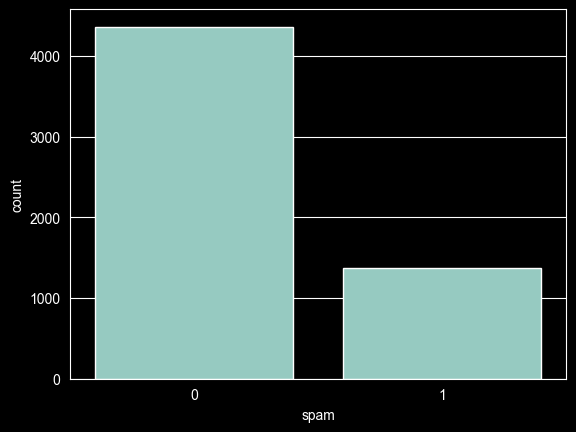

In [5]:
sns.countplot(x=df['spam'], data=df)
plt.show()


In [6]:
stop_words = set(stopwords.words('english'))

def remove_text(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word.lower() not in stop_words:
            filtered_words.append(word)

    return "".join(filtered_words)

In [7]:
df['text'] = df['text'].apply(remove_text)

df.head()

,text,spam
0,Subject:naturallyirresistiblecorporateidentity...,1
1,Subject:stocktradinggunslingerfannymerrillmuzo...,1
2,Subject:unbelievablenewhomesmadeeasyimwantings...,1
3,Subject:4colorprintingspecialrequestadditional...,1
4,"Subject:money,getsoftwarecds!softwarecompatibi...",1


In [8]:
class_weight = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['spam']),
    y=df['spam']
)

class_weight_dict = dict(enumerate(class_weight))
print("class_weight:", class_weight_dict)

class_weight: {0: np.float64(0.6568807339449542), 1: np.float64(2.0935672514619883)}


In [9]:
y = df['spam'].astype('int')
X = df['text']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

In [11]:
print("Train X shape:", train_sequences.shape)
print("Train y shape:", y_train.shape)


Train X shape: (4582, 100)
Train y shape: (4582,)


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │     2,923,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,926,945 (11.17 MB)

 Trainable params: 2,926,945 (11.17 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print(train_sequences.shape)
print(y_train.shape)

print(test_sequences.shape)
print(y_test.shape)


(4582, 100)
(4582,)
(1146, 100)
(1146,)


In [15]:
es = EarlyStopping(
    patience=3,
    monitor='val_accuracy',
    restore_best_weights=True
)

lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    factor=0.5,
    verbose=1
)

history = model.fit(
    train_sequences, y_train,
    validation_data=(test_sequences, y_test),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,  # <-- Ağırlıkları buraya ekleyin
    callbacks=[lr, es]
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9330 - loss: 0.2271 - val_accuracy: 0.7958 - val_loss: 0.5582 - learning_rate: 5.0000e-04
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9435 - loss: 0.1964 - val_accuracy: 0.8752 - val_loss: 0.4471 - learning_rate: 5.0000e-04
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9701 - loss: 0.1268 - val_accuracy: 0.8857 - val_loss: 0.4216 - learning_rate: 5.0000e-04
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9793 - loss: 0.0952 - val_accuracy: 0.8866 - val_loss: 0.4503 - learning_rate: 5.0000e-04
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9823 - loss: 0.0844 - val_accuracy: 0.8866 - val_loss: 0.4702 - learning_rate: 5.0000e-04
Epoch 6/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9837 - loss: 0.0789
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy

In [16]:
test_loss, test_accuracy = model.evaluate(test_sequences, y_test)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8866 - loss: 0.4503
Test Loss : 0.4503110349178314
Test Accuracy : 0.886561930179596


In [25]:
y_pred_prob = model.predict(test_sequences)

y_pred = (y_pred_prob > 0.5).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


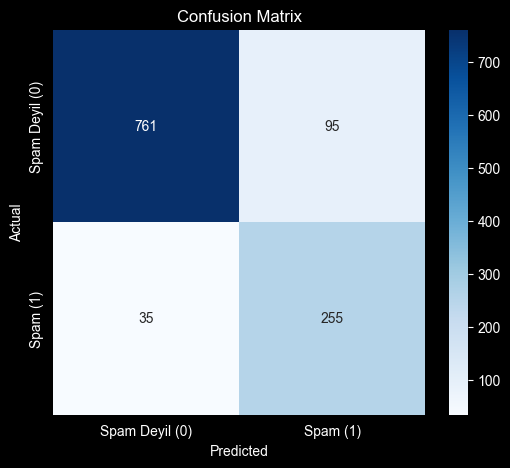

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Spam Deyil (0)', 'Spam (1)'],
            yticklabels=['Spam Deyil (0)', 'Spam (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

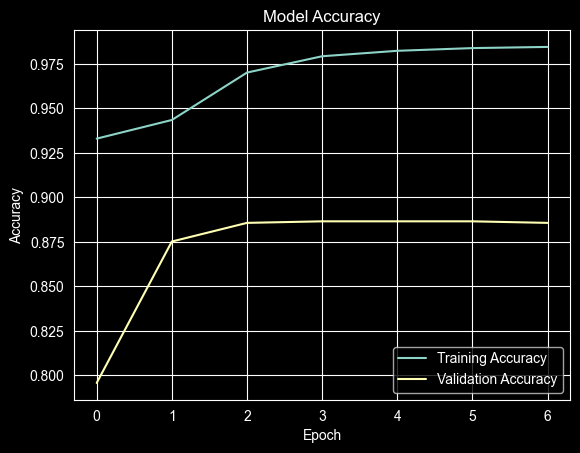

In [24]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()